# WESAD - GPU Accelerated EDA with RAPIDS
DATA 230 - Data Intelligence and Visualization
San Jose State University, Spring 2025

Benchmarks the same EDA operations from WESAD_02_EDA_Visualizations.ipynb using RAPIDS (cuDF, cuML) on GPU versus pandas and sklearn on CPU.

Run on Google Colab: Runtime -> Change runtime type -> T4 GPU

## 1. Check GPU and Install RAPIDS

In [1]:
!nvidia-smi
print()

Sat Mar 14 23:44:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q
print('RAPIDS installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 37.3 MB/s eta 0:00:00
RAPIDS installed


## 2. Upload Data

In [3]:
from google.colab import files
import os

OUTPUT_PATH = '/content/eda_plots'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print('upload wesad_features_raw.csv:')
uploaded = files.upload()
CSV_FILE  = list(uploaded.keys())[0]
print('uploaded:', CSV_FILE)
print('size    :', round(os.path.getsize(CSV_FILE) / 1024 / 1024, 2), 'MB')

upload wesad_features_raw.csv:


Saving wesad_features_raw.csv to wesad_features_raw.csv
uploaded: wesad_features_raw.csv
size    : 36.76 MB


## 3. Import Libraries

In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cudf
import cupy as cp
from sklearn.decomposition import PCA as CPU_PCA
from sklearn.preprocessing import StandardScaler as CPU_StandardScaler
from cuml.decomposition import PCA as GPU_PCA
from cuml.preprocessing import StandardScaler as GPU_StandardScaler

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

print('CPU: pandas, sklearn')
print('GPU: cuDF, cuML')

CPU: pandas, sklearn
GPU: cuDF, cuML


## 4. Config

In [5]:
feature_cols = [
    'ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max',
    'eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_slope',
    'emg_mean', 'emg_std', 'emg_rms',
    'resp_mean', 'resp_std', 'resp_range',
    'temp_mean', 'temp_std', 'temp_slope',
    'acc_x_mean', 'acc_y_mean', 'acc_z_mean', 'acc_magnitude'
]

label_order = ['baseline', 'stress', 'amusement', 'meditation']
timings     = {}

print('features:', len(feature_cols))

features: 22


## 5. Benchmark 1 - CSV Loading

In [6]:
start    = time.time()
df_cpu   = pd.read_csv(CSV_FILE)
cpu_load = time.time() - start

start    = time.time()
df_gpu   = cudf.read_csv(CSV_FILE)
gpu_load = time.time() - start

timings['CSV Loading'] = {'cpu': cpu_load, 'gpu': gpu_load}

print('CPU (pandas):', round(cpu_load, 4), 'sec | shape:', df_cpu.shape)
print('GPU (cuDF)  :', round(gpu_load, 4), 'sec | shape:', df_gpu.shape)
print('speedup     :', round(cpu_load / gpu_load, 1), 'x')

CPU (pandas): 1.9865 sec | shape: (81442, 29)
GPU (cuDF)  : 1.529 sec | shape: (81442, 29)
speedup     : 1.3 x


## 6. Benchmark 2 - Descriptive Statistics

In [7]:
start    = time.time()
desc_cpu = df_cpu[feature_cols].describe()
cpu_desc = time.time() - start

start    = time.time()
desc_gpu = df_gpu[feature_cols].describe()
gpu_desc = time.time() - start

timings['Descriptive Stats'] = {'cpu': cpu_desc, 'gpu': gpu_desc}

print('CPU (pandas):', round(cpu_desc, 4), 'sec')
print('GPU (cuDF)  :', round(gpu_desc, 4), 'sec')
print('speedup     :', round(cpu_desc / gpu_desc, 1), 'x')
print('results match:', np.allclose(desc_cpu.values, desc_gpu.to_pandas().values, rtol=1e-3))

CPU (pandas): 0.1616 sec
GPU (cuDF)  : 1.9733 sec
speedup     : 0.1 x
results match: True


## 7. Benchmark 3 - Correlation Matrix

Same operation as viz5_correlation_heatmap in EDA notebook

In [8]:
start    = time.time()
corr_cpu = df_cpu[feature_cols].corr()
cpu_corr = time.time() - start

start    = time.time()
corr_gpu = df_gpu[feature_cols].corr()
gpu_corr = time.time() - start

timings['Correlation Matrix'] = {'cpu': cpu_corr, 'gpu': gpu_corr}

print('CPU (pandas):', round(cpu_corr, 4), 'sec')
print('GPU (cuDF)  :', round(gpu_corr, 4), 'sec')
print('speedup     :', round(cpu_corr / gpu_corr, 1), 'x')
print('results match:', np.allclose(corr_cpu.values, corr_gpu.to_pandas().values, rtol=1e-3))

CPU (pandas): 0.1193 sec
GPU (cuDF)  : 1.102 sec
speedup     : 0.1 x
results match: True


## 8. Benchmark 4 - GroupBy Aggregation

Same operation as viz6_subject_variability in EDA notebook

In [9]:
start   = time.time()
grp_cpu = df_cpu.groupby(['subject', 'label_name'])[feature_cols].mean()
cpu_grp = time.time() - start

start   = time.time()
grp_gpu = df_gpu.groupby(['subject', 'label_name'])[feature_cols].mean()
gpu_grp = time.time() - start

timings['GroupBy Mean'] = {'cpu': cpu_grp, 'gpu': gpu_grp}

print('CPU (pandas):', round(cpu_grp, 4), 'sec')
print('GPU (cuDF)  :', round(gpu_grp, 4), 'sec')
print('speedup     :', round(cpu_grp / gpu_grp, 1), 'x')

CPU (pandas): 0.0336 sec
GPU (cuDF)  : 0.1033 sec
speedup     : 0.3 x


## 9. Benchmark 5 - Standard Scaling

Same operation as normalization step in extraction notebook

In [10]:
start        = time.time()
cpu_scaler   = CPU_StandardScaler()
X_cpu_scaled = cpu_scaler.fit_transform(df_cpu[feature_cols])
cpu_scale    = time.time() - start

start        = time.time()
gpu_scaler   = GPU_StandardScaler()
X_gpu_scaled = gpu_scaler.fit_transform(df_gpu[feature_cols])
gpu_scale    = time.time() - start

timings['Standard Scaling'] = {'cpu': cpu_scale, 'gpu': gpu_scale}

print('CPU (sklearn):', round(cpu_scale, 4), 'sec')
print('GPU (cuML)   :', round(gpu_scale, 4), 'sec')
print('speedup      :', round(cpu_scale / gpu_scale, 1), 'x')

CPU (sklearn): 0.0264 sec
GPU (cuML)   : 3.0742 sec
speedup      : 0.0 x


## 10. Benchmark 6 - PCA

In [11]:
start        = time.time()
cpu_pca      = CPU_PCA(n_components=2, random_state=42)
X_cpu_pca    = cpu_pca.fit_transform(X_cpu_scaled)
cpu_pca_time = time.time() - start

X_gpu_f32    = X_gpu_scaled.astype('float32')
start        = time.time()
gpu_pca      = GPU_PCA(n_components=2)
X_gpu_pca    = gpu_pca.fit_transform(X_gpu_f32)
gpu_pca_time = time.time() - start

timings['PCA (2 components)'] = {'cpu': cpu_pca_time, 'gpu': gpu_pca_time}

print('CPU (sklearn):', round(cpu_pca_time, 4), 'sec')
print('GPU (cuML)   :', round(gpu_pca_time, 4), 'sec')
print('speedup      :', round(cpu_pca_time / gpu_pca_time, 1), 'x')
print()

cpu_var = cpu_pca.explained_variance_ratio_
try:
    gpu_var = [float(v) for v in cp.asnumpy(gpu_pca.explained_variance_ratio_)]
except Exception:
    gpu_var = [float(v) for v in gpu_pca.explained_variance_ratio_.to_pandas()]

print('CPU variance explained:', round(cpu_var[0]*100, 1), '%,', round(cpu_var[1]*100, 1), '%')
print('GPU variance explained:', round(gpu_var[0]*100, 1), '%,', round(gpu_var[1]*100, 1), '%')

CPU (sklearn): 0.0278 sec
GPU (cuML)   : 0.4619 sec
speedup      : 0.1 x

CPU variance explained: 20.4 %, 15.3 %
GPU variance explained: 20.4 %, 15.3 %


## 11. Benchmark 7 - Filter and Value Counts

Same operation as viz1_class_distribution in EDA notebook

In [12]:
start = time.time()
for label in label_order:
    _ = df_cpu[df_cpu['label_name'] == label][feature_cols].mean()
_ = df_cpu['label_name'].value_counts()
cpu_filter = time.time() - start

start = time.time()
for label in label_order:
    _ = df_gpu[df_gpu['label_name'] == label][feature_cols].mean()
_ = df_gpu['label_name'].value_counts()
gpu_filter = time.time() - start

timings['Filter + Value Counts'] = {'cpu': cpu_filter, 'gpu': gpu_filter}

print('CPU (pandas):', round(cpu_filter, 4), 'sec')
print('GPU (cuDF)  :', round(gpu_filter, 4), 'sec')
print('speedup     :', round(cpu_filter / gpu_filter, 1), 'x')

CPU (pandas): 0.0483 sec
GPU (cuDF)  : 0.1521 sec
speedup     : 0.3 x


## 12. Results Table

In [13]:
timing_df = pd.DataFrame([
    {
        'Operation' : op,
        'CPU (sec)' : round(t['cpu'], 4),
        'GPU (sec)' : round(t['gpu'], 4),
        'Speedup'   : round(t['cpu'] / t['gpu'], 1) if t['gpu'] > 0 else 0
    }
    for op, t in timings.items()
])
timing_df = timing_df.sort_values('Speedup', ascending=False).reset_index(drop=True)

total_cpu = sum(t['cpu'] for t in timings.values())
total_gpu = sum(t['gpu'] for t in timings.values())

display(timing_df)
print()
print('total CPU:', round(total_cpu, 4), 'sec')
print('total GPU:', round(total_gpu, 4), 'sec')
print('overall speedup:', round(total_cpu / total_gpu, 1) if total_gpu > 0 else 0, 'x')

,Operation,CPU (sec),GPU (sec),Speedup
0,CSV Loading,1.9865,1.5290,1.3
1,Filter + Value Counts,0.0483,0.1521,0.3
2,GroupBy Mean,0.0336,0.1033,0.3
3,Correlation Matrix,0.1193,1.1020,0.1
4,Descriptive Stats,0.1616,1.9733,0.1
5,PCA (2 components),0.0278,0.4619,0.1
6,Standard Scaling,0.0264,3.0742,0.0



total CPU: 2.4035 sec
total GPU: 8.3958 sec
overall speedup: 0.3 x


## 13. Visualization 1 - Execution Time and Speedup

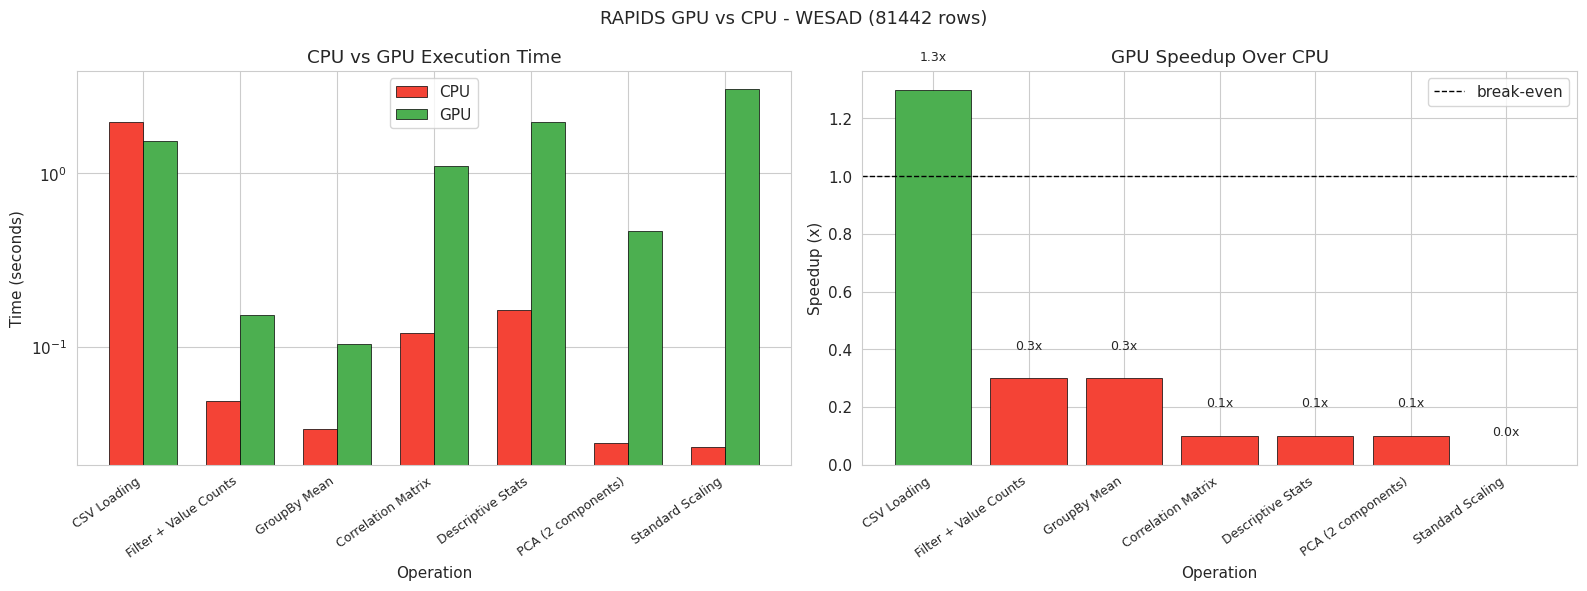

saved: rapids_cpu_vs_gpu.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ops   = timing_df['Operation'].values
x     = np.arange(len(ops))
width = 0.35

# execution time on log scale
axes[0].bar(x - width/2, timing_df['CPU (sec)'], width,
            label='CPU', color='#f44336', edgecolor='black', linewidth=0.5)
axes[0].bar(x + width/2, timing_df['GPU (sec)'], width,
            label='GPU', color='#4CAF50', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Operation')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('CPU vs GPU Execution Time')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ops, rotation=35, ha='right', fontsize=9)
axes[0].legend()
axes[0].set_yscale('log')

# speedup per operation - green = GPU faster, red = CPU faster
bar_colors = ['#4CAF50' if s > 1 else '#f44336' for s in timing_df['Speedup']]
bars = axes[1].bar(x, timing_df['Speedup'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=1, color='black', linestyle='--', linewidth=1, label='break-even')
axes[1].set_xlabel('Operation')
axes[1].set_ylabel('Speedup (x)')
axes[1].set_title('GPU Speedup Over CPU')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ops, rotation=35, ha='right', fontsize=9)
axes[1].legend()
for bar, val in zip(bars, timing_df['Speedup']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 str(val) + 'x', ha='center', fontsize=9)

fig.suptitle('RAPIDS GPU vs CPU - WESAD (' + str(len(df_cpu)) + ' rows)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'rapids_cpu_vs_gpu.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: rapids_cpu_vs_gpu.png')

## 14. Visualization 2 - Time Breakdown

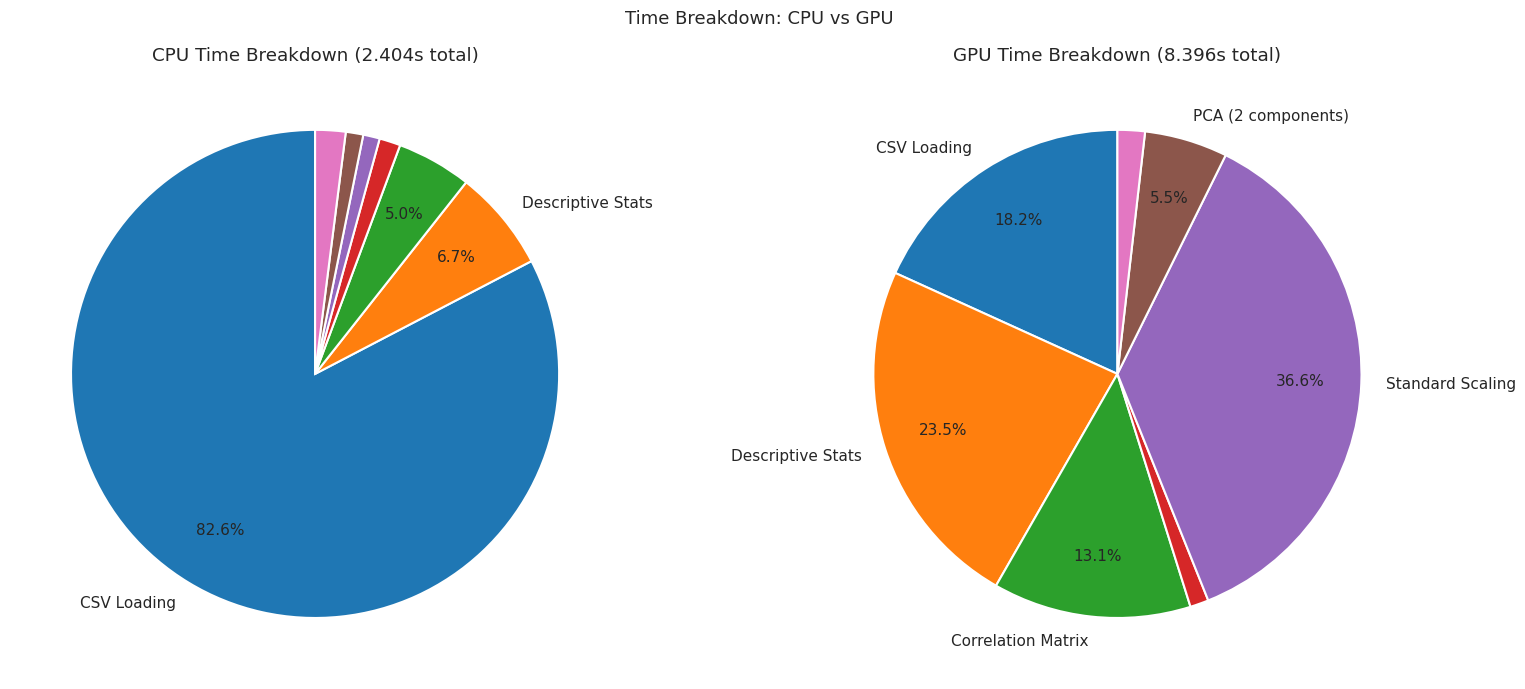

saved: rapids_time_breakdown.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

labels   = list(timings.keys())
cpu_vals = [t['cpu'] for t in timings.values()]
gpu_vals = [t['gpu'] for t in timings.values()]

# hide label text for slices smaller than 5% to avoid overlap
def make_autopct(values):
    total = sum(values)
    def autopct(pct):
        return f'{pct:.1f}%' if pct > 4 else ''
    return autopct

def label_filter(vals, lbls, threshold=5):
    total = sum(vals)
    return [l if (v/total*100) >= threshold else '' for l, v in zip(lbls, vals)]

cpu_labels = label_filter(cpu_vals, labels)
gpu_labels = label_filter(gpu_vals, labels)

axes[0].pie(
    cpu_vals,
    labels=cpu_labels,
    autopct=make_autopct(cpu_vals),
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.1,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('CPU Time Breakdown (' + str(round(total_cpu, 3)) + 's total)')

axes[1].pie(
    gpu_vals,
    labels=gpu_labels,
    autopct=make_autopct(gpu_vals),
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.1,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('GPU Time Breakdown (' + str(round(total_gpu, 3)) + 's total)')

fig.suptitle('Time Breakdown: CPU vs GPU', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'rapids_time_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: rapids_time_breakdown.png')

## 15. Scalability Analysis

8144 rows | CPU: 0.0101 s | GPU: 0.0436 s | speedup: 0.2 x
20360 rows | CPU: 0.0249 s | GPU: 0.0466 s | speedup: 0.5 x
40721 rows | CPU: 0.0517 s | GPU: 0.0459 s | speedup: 1.1 x
61081 rows | CPU: 0.0854 s | GPU: 0.0594 s | speedup: 1.4 x
81442 rows | CPU: 0.11 s | GPU: 0.0514 s | speedup: 2.1 x


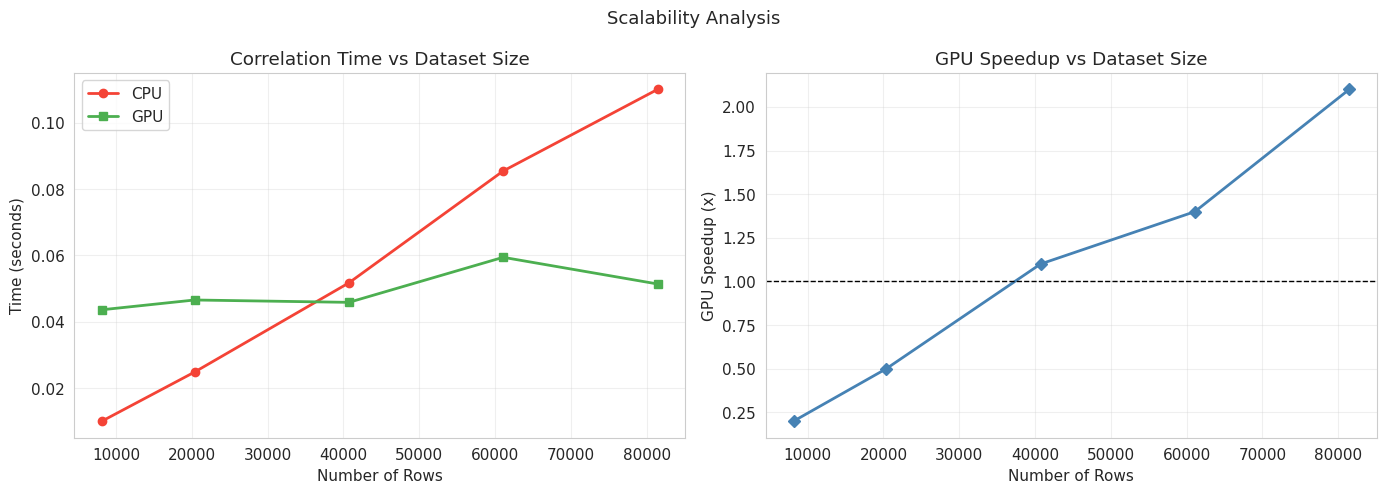

saved: rapids_scalability.png


In [20]:
# run correlation at increasing data fractions to see how speedup scales
fractions     = [0.1, 0.25, 0.5, 0.75, 1.0]
scale_results = []

for frac in fractions:
    n          = int(len(df_cpu) * frac)
    subset_cpu = df_cpu[feature_cols].iloc[:n]
    subset_gpu = df_gpu[feature_cols].iloc[:n]

    start = time.time()
    _ = subset_cpu.corr()
    t_cpu = time.time() - start

    start = time.time()
    _ = subset_gpu.corr()
    t_gpu = time.time() - start

    speedup = round(t_cpu / t_gpu, 1) if t_gpu > 0 else 0
    scale_results.append({'rows': n, 'cpu_sec': t_cpu, 'gpu_sec': t_gpu, 'speedup': speedup})
    print(n, 'rows | CPU:', round(t_cpu, 4), 's | GPU:', round(t_gpu, 4), 's | speedup:', speedup, 'x')

scale_df = pd.DataFrame(scale_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(scale_df['rows'], scale_df['cpu_sec'], 'o-', color='#f44336', linewidth=2, label='CPU')
axes[0].plot(scale_df['rows'], scale_df['gpu_sec'], 's-', color='#4CAF50', linewidth=2, label='GPU')
axes[0].set_xlabel('Number of Rows')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Correlation Time vs Dataset Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(scale_df['rows'], scale_df['speedup'], 'D-', color='steelblue', linewidth=2)
axes[1].axhline(y=1, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Number of Rows')
axes[1].set_ylabel('GPU Speedup (x)')
axes[1].set_title('GPU Speedup vs Dataset Size')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Scalability Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'rapids_scalability.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: rapids_scalability.png')

## 16. Summary

In [21]:
print('dataset     :', len(df_cpu), 'rows,', len(feature_cols), 'features')
print('GPU         : NVIDIA T4 (Google Colab)')
print()
for _, row in timing_df.iterrows():
    print(row['Operation'].ljust(25),
          'CPU:', row['CPU (sec)'], 's',
          'GPU:', row['GPU (sec)'], 's',
          '->', row['Speedup'], 'x')
print()
overall = round(total_cpu / total_gpu, 1) if total_gpu > 0 else 0
print('overall speedup:', overall, 'x')

dataset     : 81442 rows, 22 features
GPU         : NVIDIA T4 (Google Colab)

CSV Loading               CPU: 1.9865 s GPU: 1.529 s -> 1.3 x
Filter + Value Counts     CPU: 0.0483 s GPU: 0.1521 s -> 0.3 x
GroupBy Mean              CPU: 0.0336 s GPU: 0.1033 s -> 0.3 x
Correlation Matrix        CPU: 0.1193 s GPU: 1.102 s -> 0.1 x
Descriptive Stats         CPU: 0.1616 s GPU: 1.9733 s -> 0.1 x
PCA (2 components)        CPU: 0.0278 s GPU: 0.4619 s -> 0.1 x
Standard Scaling          CPU: 0.0264 s GPU: 3.0742 s -> 0.0 x

overall speedup: 0.3 x


## 17. Download PNG Files

Run after all benchmarks finish. Move downloaded files to:
/Users/rishitha/anaconda_projects/WESAD/output/eda_plots/

In [22]:
from google.colab import files

png_files = sorted([f for f in os.listdir(OUTPUT_PATH) if f.endswith('.png')])
for fname in png_files:
    files.download(os.path.join(OUTPUT_PATH, fname))
    print('downloaded:', fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloaded: rapids_cpu_vs_gpu.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloaded: rapids_scalability.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloaded: rapids_time_breakdown.png


## AI Use Acknowledgement

We used Claude AI to help structure the RAPIDS benchmarking approach. All interpretation of results and insights are our own.

Prompt used: "Help me create a RAPIDS GPU vs CPU comparison notebook for our WESAD EDA that benchmarks the same operations from our original EDA notebook."